# Phase 2 — Treatment-aware analysis (figures)

Is the LM-extracted risk score (MedGemma, tab⊕emb) **prognostic** (it separates survival
within each therapy) or **predictive** (its effect is modified by the therapy)? This notebook
**does not recompute the statistics**: it reads `results/treatment_analysis.json` (produced by
`scripts/30_treatment_analysis.py`) and, for the KM curves, the per-patient table
`data/processed/treatment_oof_patients.parquet` (out-of-fold risk + survival, gitignored).

⚠️ **Caveat (goes in the paper):** `TREATMENT_HISTORY` is post-baseline (living longer → receiving
more lines) → the treatment strata carry *immortal-time bias*. The framing is stratified prognostic
validation + the interaction as an effect-modification probe, NOT a causal claim about treatment efficacy.

Three figures:
- **Figure 1** — high/low risk KM for pancreas, within each regimen (does the score separate OS in each therapy?).
- **Figure 2** — adjusted HR of the score (per SD) by tumor (pan-cancer vs cancer-specific).
- **Figure 3** — risk×treatment interaction term (prognostic vs predictive).

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
import pandas as pd
from embedbiomarker import analysis as A

data = json.loads((REPO / "results/treatment_analysis.json").read_text())
pts = pd.read_parquet(REPO / "data/processed/treatment_oof_patients.parquet")
tax = A.load_treatment_taxonomy(REPO / "config/treatments.yaml")
print("model:", data["model"], "| risk modes:", data["risk_modes"], "| n:", data["n_patients"])

SHORT = {
    "Pancreatic Cancer": "Pancreas", "Breast Cancer": "Breast",
    "Colorectal Cancer": "Colorectal", "Non-Small Cell Lung Cancer": "NSCLC",
    "Prostate Cancer": "Prostate",
}
PANC = "Pancreatic Cancer"
REGIMEN_ORDER = ["FOLFIRINOX-like", "gemcitabine-based", "other-treated", "untreated"]

model: medgemma15 | risk modes: ['pan', 'specific'] | n: 23777


## Figure 1 — High/low risk KM for pancreas, within each regimen

One panel per regimen. In each, the patients of that regimen are split into **high/low risk by the
median of the pancreas score** (a single cutpoint per tumor, as a biomarker would be used in the clinic)
and their Kaplan-Meier curves are drawn. The log-rank *p* comes from the JSON. If the curves separate
**within each therapy**, the score is prognostic regardless of the treatment received — the result that
supports the biomarker.

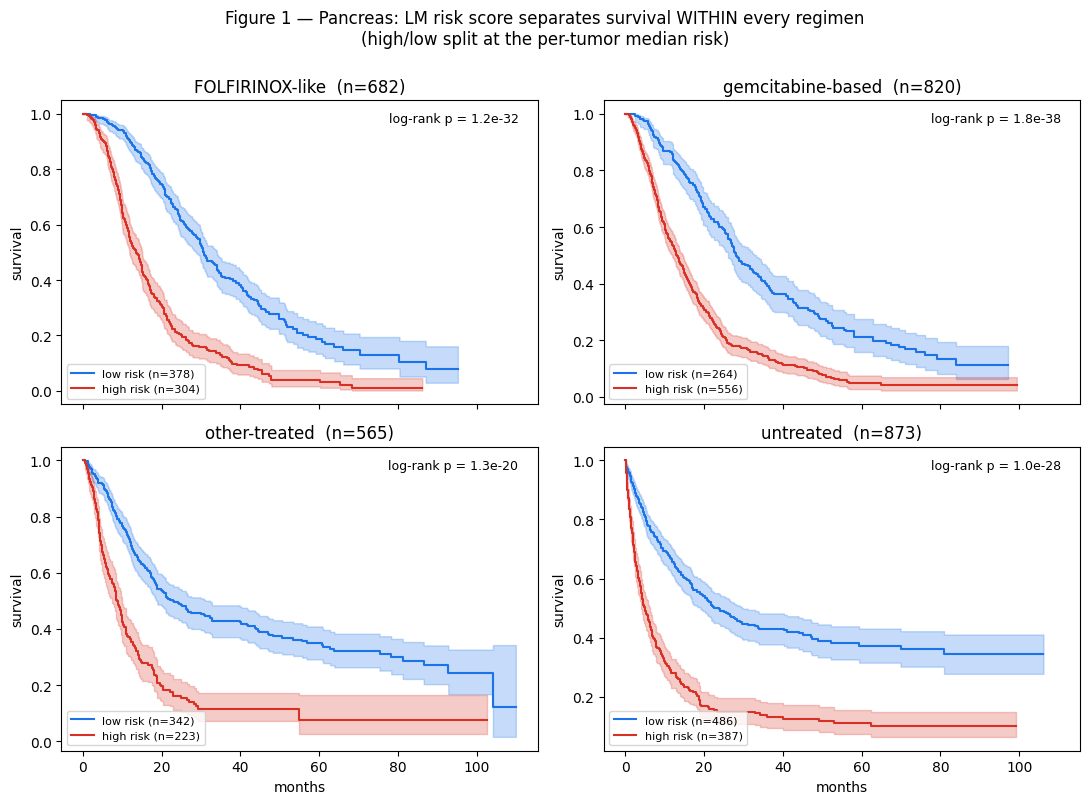

In [2]:
# pancreas patients + regimen label (from the shared taxonomy) + per-tumor median cutpoint
panc = pts[pts["CANCER_TYPE"] == PANC].reset_index(drop=True)
_, regimen = A.treatment_strata(panc, tax[PANC])
panc = panc.assign(regimen=regimen.to_numpy())
cut = float(np.median(panc["risk_pan"]))           # per-tumor cutpoint
panc = panc.assign(grp=np.where(panc["risk_pan"] > cut, "high", "low"))

strata_json = data["per_cancer"][PANC]["by_risk_mode"]["pan"]["strata"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
kmf = KaplanMeierFitter()
for ax, arm in zip(axes.ravel(), REGIMEN_ORDER):
    sub = panc[panc["regimen"] == arm]
    for grp, color in (("low", "#1a73e8"), ("high", "#d93025")):
        g = sub[sub["grp"] == grp]
        if len(g) == 0:
            continue
        kmf.fit(g["os_months"], g["event"], label=f"{grp} risk (n={len(g)})")
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
    p = strata_json.get(arm, {}).get("km_high_low", {}).get("logrank_p")
    ptxt = f"log-rank p = {p:.1e}" if p is not None else "log-rank n/a"
    ax.set_title(f"{arm}  (n={len(sub)})")
    ax.text(0.96, 0.96, ptxt, transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.set_xlabel("months"); ax.set_ylabel("survival")
    ax.legend(loc="lower left", fontsize=8)

fig.suptitle("Figure 1 — Pancreas: LM risk score separates survival WITHIN every regimen\n"
             "(high/low split at the per-tumor median risk)", y=1.0)
plt.tight_layout()
plt.show()

**Interpretation (Figure 1).** If in all four panels the low-risk curve (blue) stays above the high-risk
one (red) with a significant log-rank, the LM score is **prognostic within each regimen** — not an
artifact of one group receiving better treatment. This is the validation that turns the Phase 1 finding
into a per-stratum actionable biomarker.

## Figure 2 — Adjusted HR of the score (per SD), by tumor

HR of the risk score per standard deviation, **adjusted for age + stage** (Cox, lifelines), global per
tumor. The two OOF models are compared: **pan-cancer** (one model for the 5) vs **cancer-specific** (one
per tumor). HR>1 = higher predicted risk → worse survival. Line at 1 = no effect.

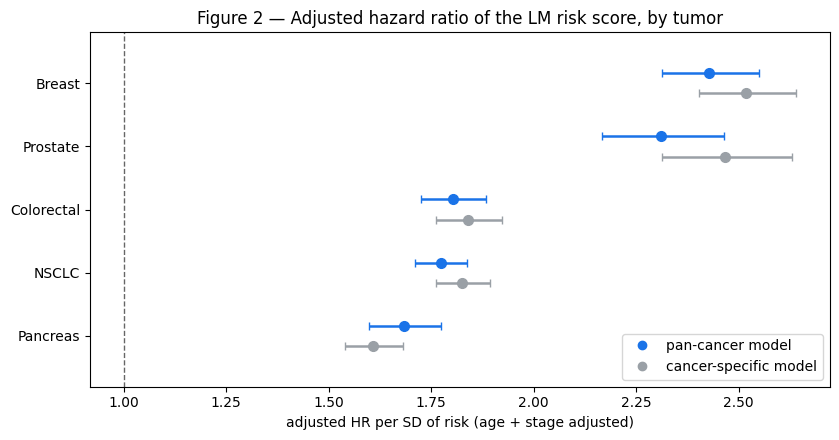

In [3]:
cancers = [c for c in SHORT if c in data["per_cancer"]]
order = sorted(cancers, key=lambda c: data["per_cancer"][c]["by_risk_mode"]["pan"]["global"]["adjusted_hr"]["hr_per_sd"], reverse=True)
y = np.arange(len(order))[::-1]
OFF = 0.16
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for mode, color, off in (("pan", "#1a73e8", +OFF), ("specific", "#9aa0a6", -OFF)):
    for yi, c in zip(y, order):
        hr = data["per_cancer"][c]["by_risk_mode"].get(mode, {}).get("global", {}).get("adjusted_hr")
        if not hr:
            continue
        xerr = [[hr["hr_per_sd"] - hr["ci_low"]], [hr["ci_high"] - hr["hr_per_sd"]]]
        ax.errorbar(hr["hr_per_sd"], yi + off, xerr=xerr, fmt="o", color=color,
                    capsize=3, ms=7, lw=1.8)
ax.axvline(1.0, color="k", lw=1, ls="--", alpha=0.6)
ax.set_yticks(y); ax.set_yticklabels([SHORT[c] for c in order])
ax.set_xlabel("adjusted HR per SD of risk (age + stage adjusted)")
ax.set_title("Figure 2 — Adjusted hazard ratio of the LM risk score, by tumor")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker="o",color="#1a73e8",lw=0,label="pan-cancer model"),
                   Line2D([0],[0],marker="o",color="#9aa0a6",lw=0,label="cancer-specific model")],
          loc="lower right", frameon=True)
ax.margins(y=0.15); plt.tight_layout(); plt.show()

## Figure 3 — Risk×treatment interaction (prognostic vs predictive)

Interaction term of the Cox `risk×treatment` (HR and 95% CI), per stratum. Pancreas by regimen, breast by
drug class. **A CI that crosses 1 → no effect modification = the score is purely prognostic** in that
stratum. A CI that excludes 1 → effect modification (a *predictive* flavor): the weight of the score
changes with the therapy. Given the immortal-time caveat, it is read as exploratory signal, not causal.

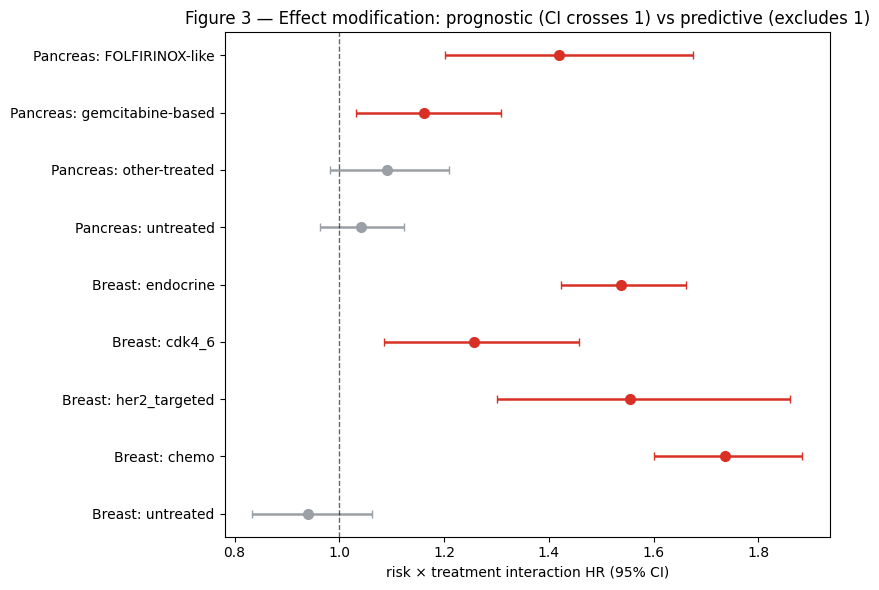

In [4]:
def interaction_rows(cancer, mode="pan"):
    out = []
    strata = data["per_cancer"][cancer]["by_risk_mode"][mode]["strata"]
    for name, s in strata.items():
        it = s.get("interaction")
        if it:
            out.append((f"{SHORT[cancer]}: {name}", it))
    return out

rows = interaction_rows(PANC) + interaction_rows("Breast Cancer")
labels = [r[0] for r in rows]
y = np.arange(len(rows))[::-1]
fig, ax = plt.subplots(figsize=(8.5, 0.5 * len(rows) + 1.5))
for yi, (_, it) in zip(y, rows):
    sig = (it["ci_low"] > 1.0) or (it["ci_high"] < 1.0)
    color = "#d93025" if sig else "#9aa0a6"
    xerr = [[it["interaction_hr"] - it["ci_low"]], [it["ci_high"] - it["interaction_hr"]]]
    ax.errorbar(it["interaction_hr"], yi, xerr=xerr, fmt="o", color=color, capsize=3, ms=7, lw=1.8)
ax.axvline(1.0, color="k", lw=1, ls="--", alpha=0.6)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("risk × treatment interaction HR (95% CI)")
ax.set_title("Figure 3 — Effect modification: prognostic (CI crosses 1) vs predictive (excludes 1)")
plt.tight_layout(); plt.show()

## Defensible conclusion

- **Prognostic, robust:** the LM score separates survival **within each regimen/class** (Figure 1) and
  keeps an adjusted HR > 1 per tumor (Figure 2), with consistent results between the pan-cancer and the
  cancer-specific model.
- **Predictive?** Figure 3 marks where the effect is modified by the therapy (CI excluding 1) —
  exploratory signal, conditioned by the immortal-time bias of the treatment history.

→ Phase 2 turns the Phase 1 finding (the LM extracts semantic signal, strong in pancreas) into its
clinical reading: a prognostic biomarker stratified by treatment.